<a href="https://colab.research.google.com/github/PunamBhatia/LogicMojo-AI-ML-April26-Punam/blob/main/Applied_CNNs_Parcel_Label_Digit_Recognition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:

from copy import deepcopy
from pathlib import Path

import random
import time

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import sklearn

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

from sklearn.datasets import load_digits
from sklearn.metrics import classification_report, confusion_matrix

from sklearn.model_selection import train_test_split



SEED=42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    device= torch.device('cuda')
elif torch.backends.mps.is_available():
    device= torch.device('mps')
else:
    device= torch.device('cpu')

print(f"PyTorch version: {torch.__version__}")
print(f"sklearn versoin: {sklearn.__version__}")
print(f"Device: {device}")

PyTorch version: 2.11.0+cpu
sklearn versoin: 1.6.1
Device: cpu


In [2]:
#Load the digit images and inspect the raw data contract.
digits= load_digits()
print(digits.images.shape)#return 2D array of images 8*8
print(digits.data.shape)# returns flatten image data as 1D array with 64 entries
print(digits.target_names)

X_raw=digits.images
y_raw=digits.target
class_names=np.array([str(value) for value in digits.target_names])

#lets check class balance in target column
unique_classes, class_counts=np.unique(y_raw, return_counts=True)

print(f"Images: {X_raw.shape} | dtype: {X_raw.dtype}")
print(f"Pixel range: [{X_raw.min():.1f}, {X_raw.max():.1f}]")

print(f"Labels: {y_raw.shape} | dtype: {y_raw.dtype}")
print(f"Classes: {class_names.tolist()}")
print(f"Unique classes: {unique_classes}")
print("Class counts:", dict(zip(unique_classes.tolist(), class_counts.tolist())))



(1797, 8, 8)
(1797, 64)
[0 1 2 3 4 5 6 7 8 9]
Images: (1797, 8, 8) | dtype: float64
Pixel range: [0.0, 16.0]
Labels: (1797,) | dtype: int64
Classes: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']
Unique classes: [0 1 2 3 4 5 6 7 8 9]
Class counts: {0: 178, 1: 182, 2: 177, 3: 183, 4: 181, 5: 182, 6: 181, 7: 179, 8: 174, 9: 180}


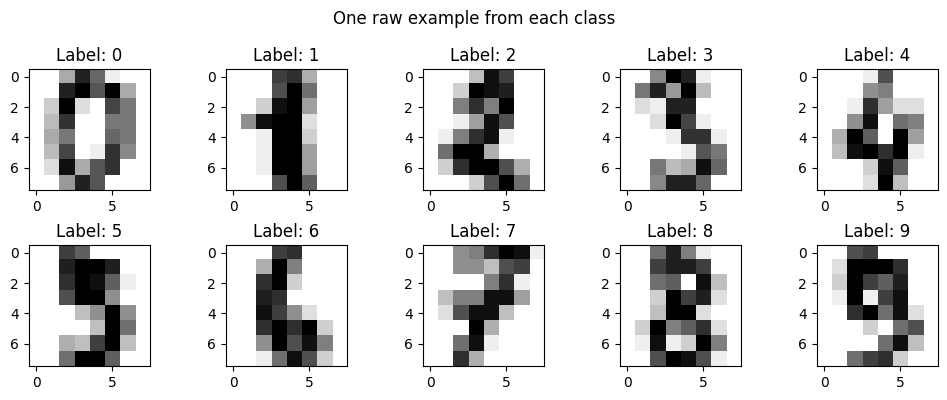

In [3]:
#lets  display one example from each class.

fig, axes= plt.subplots(nrows=2, ncols=5, figsize=(10,4))
for digit, axis in enumerate(axes.flat):
  sample_index=np.flatnonzero(y_raw==digit)[0]
  axis.imshow(X_raw[sample_index], cmap='binary')
  axis.set_title(f"Label: {y_raw[sample_index]}")
  axis.set_title(f"Label: {digit}")
  #axis.axis("off")

plt.suptitle("One raw example from each class")
plt.tight_layout()
plt.show()

In [4]:
#lets create train, test and validation split
#  The training set updates weights, validation selects the best epoch and engineering choices,
#  and the test set stays untouched until final evaluation.
#The final image contract is [N, 1, 8, 8]
X_train, X_test, y_train, y_test= train_test_split(X_raw, y_raw, test_size=0.30, random_state=SEED)
X_valid, X_test, y_valid, y_test= train_test_split(X_test, y_test, test_size=0.50, random_state=SEED)

#scale images and conver to tensor
def prepare_images(images):
  #print("Images:", images)
  scaled= images.astype(np.float32)/16.0
  #print("Scaled:", scaled)
  return torch.from_numpy(scaled).unsqueeze(1)

X_train= prepare_images(X_train)
X_valid= prepare_images(X_valid)
X_test= prepare_images(X_test)

y_train= torch.from_numpy(y_train)
y_valid= torch.from_numpy(y_valid)
y_test= torch.from_numpy(y_test)

print("Train : ",X_train.shape, y_train.shape)
print("Valid : ",X_valid.shape, y_valid.shape)
print("Test : ",X_test.shape, y_test.shape)
print(f" Scaled train range: [{X_train.min():.2f}, {X_train.max():.2f}]")

Train :  torch.Size([1257, 1, 8, 8]) torch.Size([1257])
Valid :  torch.Size([270, 1, 8, 8]) torch.Size([270])
Test :  torch.Size([270, 1, 8, 8]) torch.Size([270])
 Scaled train range: [0.00, 1.00]


In [5]:
#lets build mini batches
#Only the training loader shuffles. Validation and test order do not affect metrics
#Wrap tensors in datasets and create deterministic data loaders.

BATCH_SIZE=64
loader_generator=torch.Generator()
train_loader=DataLoader(TensorDataset(X_train, y_train), batch_size=BATCH_SIZE, shuffle=True, generator=loader_generator)
valid_loader=DataLoader(TensorDataset(X_valid, y_valid), batch_size=BATCH_SIZE, shuffle=False, generator=loader_generator)
test_loader=DataLoader(TensorDataset(X_test, y_test), batch_size=BATCH_SIZE, shuffle=False, generator=loader_generator)


batch_images, batch_labels = next(iter(train_loader))
print("Image batch:", batch_images.shape)
print("Label batch:", batch_labels.shape)
print("First labels:", batch_labels[:10].tolist())

Image batch: torch.Size([64, 1, 8, 8])
Label batch: torch.Size([64])
First labels: [4, 4, 7, 2, 0, 2, 1, 2, 1, 2]


Edge response: torch.Size([1, 1, 8, 8])


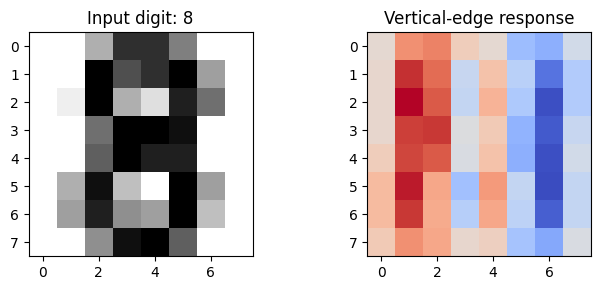

Input shape: torch.Size([1, 1, 8, 8])
Kernel shape: torch.Size([1, 1, 3, 3])
Response shape: torch.Size([1, 1, 8, 8])


In [6]:
#lets apply a fixed vertical-edge kernel to one normalized image.

example_image = X_train[0:1]  # [N=1, C=1, H=8, W=8]
vertical_edge_kernel = torch.tensor(
    [[-1.0, 0.0, 1.0],
     [-1.0, 0.0, 1.0],
     [-1.0, 0.0, 1.0]],
    dtype=torch.float32,
).reshape(1, 1, 3, 3)

edge_response= F.conv2d(example_image, vertical_edge_kernel, padding=1)
print("Edge response:", edge_response.shape)

fig,axes= plt.subplots(nrows=1, ncols=2, figsize=(7,3))
axes[0].imshow(example_image[0,0] , cmap='gray_r')
axes[0].set_title(f"Input digit: {y_train[0]}")
axes[1].imshow(edge_response[0, 0], cmap="coolwarm")
axes[1].set_title("Vertical-edge response")
plt.tight_layout()
plt.show()


print(f"Input shape: {example_image.shape}")
print(f"Kernel shape: {vertical_edge_kernel.shape}")
print(f"Response shape: {edge_response.shape}")

In [7]:
class SmallCNN(nn.Module):
   def __init__(self, num_classes=10, dropout=0.20):
    super().__init__()
    self.num_classes=num_classes
    self.dropout=dropout
    self.features= nn.Sequential(
        nn.Conv2d(in_channels=1, out_channels=16, kernel_size=3, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2),
        nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2),
    )

    self.classifier=nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features=32*2*2, out_features=64),
        nn.ReLU(),
        nn.Dropout(p=self.dropout),
       nn.Linear(in_features=64, out_features=self.num_classes),
    )

   def forward(self, images):
    features= self.features(images)
    return self.classifier(features)

model =SmallCNN(num_classes=10, dropout=0.20).to(device)
print(model)


SmallCNN(
  (features): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=128, out_features=64, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=64, out_features=10, bias=True)
  )
)


In [8]:
#Define reusable training and evaluation functions.
def train_one_epoch(model, loader, criterion, optimizer, device):
  model.train()
  total_loss=0.0
  total_correct=0.0
  total_samples=0.0

  for images, labels in loader:
    images= images.to(device)
    labels= labels.to(device)

    optimizer.zero_grad()
    logits= model(images)
    loss= criterion(logits, labels)
    loss.backward()
    optimizer.step()

    batch_size=labels.size(0)
    total_loss+=loss.item()*batch_size
    _, predictions= torch.max(logits, dim=1)
    total_correct+=torch.sum(predictions==labels).item()
    total_samples+=batch_size

  return (total_loss/total_samples),(total_correct/total_samples)


def evaluate(model, loader, criterion, device):
  model.eval()
  total_loss=0.0
  total_correct=0
  total_samples=0
  all_labels=[]
  all_predictions=[]
  all_logits=[]

  with torch.inference_mode():
    for images, labels in loader:
      images=images.to(device)
      labels=labels.to(device)
      logits= model(images)
      loss= criterion(logits, labels)
      predictions= torch.argmax(logits, dim=1)

      batch_size=labels.size(0)
      total_loss+=loss.item()*batch_size
      total_correct+=torch.sum(predictions==labels).item()
      total_samples+=batch_size

      all_labels.append(labels.cpu())
      all_predictions.append(predictions.cpu())
      all_logits.append(logits.cpu())

  return {
    "loss" : total_loss / total_samples,
    "accuracy": total_correct / total_samples,
    "labels": torch.cat(all_labels),
    "predictions": torch.cat(all_predictions),
    "logits": torch.cat(all_logits)
    }



In [9]:
#Now lets train the CNN, select the lowest validation-loss state, and stop on a plateau.

criterion= nn.CrossEntropyLoss()
optimizer= torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
#scheduler= torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer,
MAX_EPOCHS=30
PATIENCE=6
history={"train_loss":[],"validation_loss":[], "train_accuracy":[], "validation_accuracy":[]}
best_loss=float('inf')
best_epoch=0
best_state=None
epochs_without_improvement=0

for epoch in range(MAX_EPOCHS+1):
  train_loss, train_accuracy= train_one_epoch(model, train_loader, criterion, optimizer, device)
  validation_metrics= evaluate(model, valid_loader, criterion, device)

  validation_loss= validation_metrics["loss"]
  validation_accuracy= validation_metrics["accuracy"]

  history["train_loss"].append(train_loss)
  history["validation_loss"].append(validation_loss)
  history["train_accuracy"].append(train_accuracy)
  history["validation_accuracy"].append(validation_accuracy)

  print(f'''Epoch: {epoch}, train loss: {train_loss}, valid loss: {validation_loss},
  train acc={train_accuracy},  valid acc:{validation_accuracy}''')

  is_loss_improved= validation_loss<best_loss
  if is_loss_improved:
    best_loss=validation_loss
    best_epoch=epoch
    best_state=deepcopy(model.state_dict())
    epochs_without_improvement=0
  else:
    epochs_without_improvement+=1

  if epochs_without_improvement>=PATIENCE:
    print(f"Early stopping at epoch {epoch}")
    break

print(f"Best epoch: {best_epoch} | Best loss: {best_loss:.4f}")
#

Epoch: 0, train loss: 2.2925450462335237, valid loss: 2.2794061254571987,
  train acc=0.12649164677804295,  valid acc:0.0962962962962963
Epoch: 1, train loss: 2.2403828077308696, valid loss: 2.209849728478326,
  train acc=0.18377088305489261,  valid acc:0.3925925925925926
Epoch: 2, train loss: 2.097402131547981, valid loss: 1.9808618156998246,
  train acc=0.4343675417661098,  valid acc:0.5666666666666667
Epoch: 3, train loss: 1.7281221243343186, valid loss: 1.4586577468448214,
  train acc=0.5672235481304694,  valid acc:0.6888888888888889
Epoch: 4, train loss: 1.2160301928303976, valid loss: 0.9671539306640625,
  train acc=0.6801909307875895,  valid acc:0.7814814814814814
Epoch: 5, train loss: 0.8866413483187237, valid loss: 0.6931921349631416,
  train acc=0.7533810660302307,  valid acc:0.7925925925925926
Epoch: 6, train loss: 0.6626926815120967, valid loss: 0.530010414565051,
  train acc=0.807478122513922,  valid acc:0.8629629629629629
Epoch: 7, train loss: 0.5700730172622365, valid lo

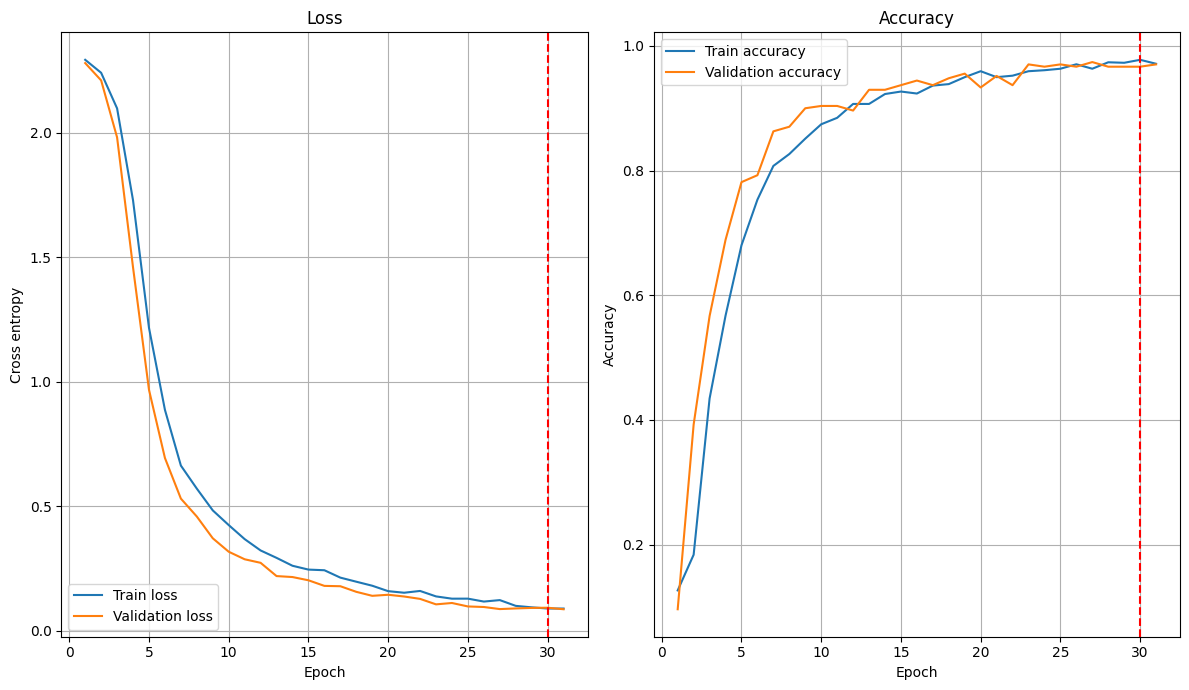

In [10]:
#plot training  and validation curve
# Side-by-side loss and accuracy curves with the selected epoch marked.
#Curves reveal underfitting, overfitting, instability, and the effect of early stopping.
completed_epochs = np.arange(1, len(history["train_loss"]) + 1)

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12,7))

axes[0].plot(completed_epochs, history["train_loss"], label="Train loss")
axes[0].plot(completed_epochs, history["validation_loss"], label="Validation loss")
axes[0].set(title="Loss", xlabel="Epoch", ylabel="Cross entropy")
axes[0].legend()

axes[0].axvline(x=best_epoch, color="red", linestyle="--", label="Selected epoch")
axes[0].grid(True)


axes[1].plot(completed_epochs, history["train_accuracy"], label="Train accuracy")
axes[1].plot(completed_epochs, history["validation_accuracy"], label="Validation accuracy")
axes[1].set(title="Accuracy", xlabel="Epoch", ylabel="Accuracy")
axes[1].legend()

axes[1].axvline(x=best_epoch, color="red", linestyle="--", label="Selected epoch")
axes[1].grid(True)

plt.tight_layout()
plt.show()



In [11]:
#Now lets restore the best validation state and compute test metrics
#Restore the best weights and calculate final test predictions.
model.load_state_dict(best_state)
model.to(device)
test_metrics= evaluate(model, test_loader, criterion, device)
test_loss= test_metrics["loss"]
test_accuracy= test_metrics["accuracy"]
test_predictions= test_metrics["predictions"]
y_test_eval=test_metrics["labels"].numpy()
test_probabilities = torch.softmax(test_metrics["logits"], dim=1).numpy()
test_confidences = test_probabilities.max(axis=1)

print(f"Test loss: {test_loss:.4f} | Test accuracy: {test_accuracy:.4f}")

#


Test loss: 0.0850 | Test accuracy: 0.9815


              precision    recall  f1-score   support

           0      1.000     1.000     1.000        31
           1      0.960     1.000     0.980        24
           2      1.000     1.000     1.000        27
           3      1.000     0.970     0.985        33
           4      0.967     1.000     0.983        29
           5      0.963     0.963     0.963        27
           6      1.000     0.957     0.978        23
           7      1.000     1.000     1.000        27
           8      0.960     0.960     0.960        25
           9      0.958     0.958     0.958        24

    accuracy                          0.981       270
   macro avg      0.981     0.981     0.981       270
weighted avg      0.982     0.981     0.981       270



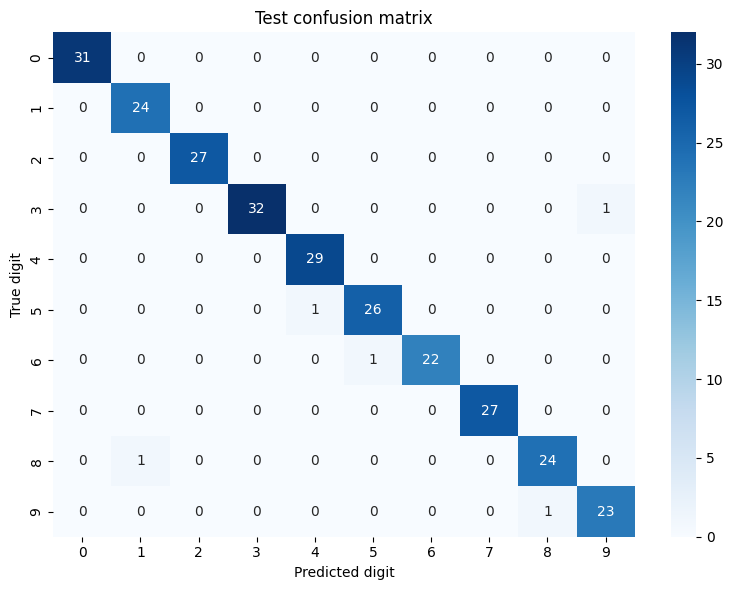

In [12]:
#lets print  per-class metrics and draw the confusion matrix.
# Precision, recall, F1-score, support, and a labeled confusion matrix.
print(classification_report(
    y_test_eval,
    test_predictions,
    labels=np.arange(10),
    target_names=class_names,
    digits=3,
    zero_division=0,
))

matrix= confusion_matrix(y_test_eval, test_predictions, labels=np.arange(10))
plt.figure(figsize=(8, 6))
sns.heatmap(
    matrix,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
)
plt.xlabel("Predicted digit")
plt.ylabel("True digit")
plt.title("Test confusion matrix")
plt.tight_layout()
plt.show()



0 2 0
Misclassified examples: 1 out of 270


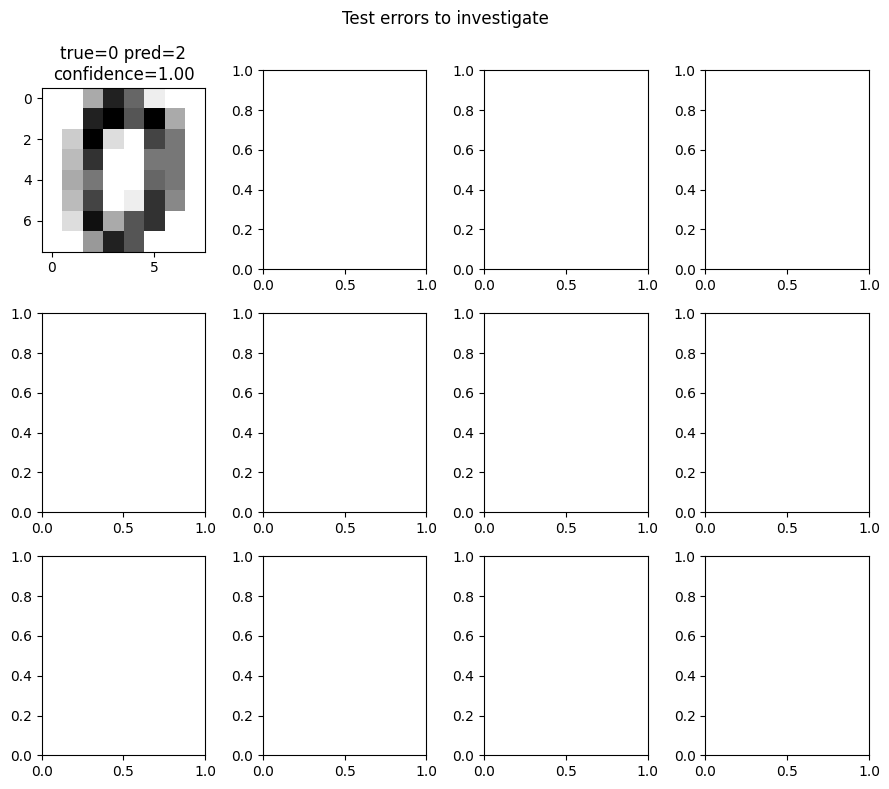

In [17]:
#Lets Inspect mistakes instead of only tuning the model
#Display up to twelve misclassified test images with confidence
#For each mistake, inspect the image, true class, predicted class, and confidence.
#Look for ambiguous writing, weak strokes, crop problems, label noise, or a repeated confusion pattern

mistake_indices=np.flatnonzero(test_predictions!=y_test_eval)
print(mistake_indices[0], y_test_eval[mistake_indices[0]],y_raw[mistake_indices[0]] )
print(f"Misclassified examples: {len(mistake_indices) } out of {len(y_test_eval)}")

if len(mistake_indices) == 0:
    print("No mistakes to display in this split.")
else:
    images_to_show=mistake_indices[:12]
    fig, axes= plt.subplots(nrows=3, ncols=4, figsize=(9, 8))

    for axis, image_index,  in zip( axes.flat,images_to_show):
       axis.imshow(X_raw[image_index], cmap='gray_r')
       axis.set_title(
            f"true={y_raw[image_index]} pred={test_predictions[image_index]}\n"
            f"confidence={test_confidences[image_index]:.2f}"
        )

    plt.suptitle("Test errors to investigate")
    plt.tight_layout()
    plt.show()


In [25]:
#lets create a single image prediction function
# Wrap preprocessing, inference, top-k probabilities, and the review decision
#One structured prediction for a raw 8x8 image.

def predict_digit(model, raw_image, threshold=0.80, device=device):
  print(raw_image.shape)
  image_to_pred=np.asarray(raw_image)
  print(image_to_pred.shape)
  if(image_to_pred.shape!=(8, 8)):
    raise ValueError(f"Expected shape (8, 8) received {raw_image.shape}")
  if(raw_image.min() < 0 or raw_image.max()> 16):
    raise ValueError(f"Expected raw pixel values in the range [0,16]")

  image_tensor=torch.from_numpy(raw_image.astype(np.float32)/16.0).unsqueeze(0).unsqueeze(0).to(device)

  model.eval()
  with torch.inference_mode():
    logits= model(image_tensor)
    probabilities=torch.softmax(logits, dim=1)[0]
    confidence, predicted_index = probabilities.max(dim=0)
    top_probabilities, top_indices= torch.topk(probabilities, k=3)
    confidence_value = float(confidence.cpu())

  return {
        "prediction": class_names[int(predicted_index.cpu())],
        "confidence": confidence,
        "decision": "accept" if confidence >= threshold else "review",
        "top_3": [
            (class_names[int(index)], float(value))
            for value, index in zip(top_probabilities.cpu(), top_indices.cpu())
        ]}

sample_result = predict_digit(model, X_raw[0], threshold=0.80)
print("True label:", y_raw[0])
print("Prediction result:", sample_result)

(8, 8)
(8, 8)
True label: 0
Prediction result: {'prediction': np.str_('0'), 'confidence': tensor(0.9993), 'decision': 'accept', 'top_3': [(np.str_('0'), 0.9993031024932861), (np.str_('5'), 0.00038795528234913945), (np.str_('9'), 0.00012390923802740872)]}
